# 03_mining v_final — Spearman·OLS·ordered·binary + 알파(업종 분해)

> **사이클 4 — 팀 회의용 최종**

## v_final 변경점 (v1 → v_final)
- 🆕 **OLS + ordered_logit + binary_logit 3 모형 동시 비교** (가이드 03 line 220-274)
- 🆕 **AIC·BIC 정량 비교** 표
- 🆕 **알파 #1: 업종별 분해** (가이드 04 §3-1 명시 예시)
- 🆕 **seed_tfidf vs expanded_tfidf 회귀 비교** (가이드 03 line 132 다중공선성 회피)

## 산출
- regression_results_v_final.csv
- fig_v_final_mining_*.png 3종 (Spearman·OLS·업종 분해)


---
## 🔧 사이클 4 안정성 fix (사이클 2·3에서 발견한 6가지 fix 통합)

### Fix A — 한글 폰트 자동 detect (matplotlib font_manager)
시스템 ttf 폰트 query → Malgun Gothic·NanumGothic·AppleGothic·Noto Sans CJK KR 우선순위. 미설치 시 후보 알림.

### Fix B — stock_code dtype=str + zfill(6)
모든 read_csv·to_excel 후 강제. silent 오매칭 (위반금지 #7) 차단.

### Fix C — KCGS 메모 dynamic 출력
하드코딩 안내문 제거, 실제 데이터 그대로 출력.

### Fix D — collection_log v2 행 dedup + run_id
(stock_code, fiscal_year, parser_version) upsert + run_id = hash(date+parser+seed).

### Fix E — pandas display 제한 + display→print
max_rows=10, max_colwidth=80 강제. truncation 방지.

### 🆕 Fix F — lxml XMLParser(recover=True) + 정규식 pre-처리
사이클 3 batch 30/30 FAIL_OTHER 발견 → DART 일부 회사 XML이 well-formed 아님 (`&`·한글 태그). recover mode + `re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', text)` pre-처리.


In [1]:
# 사이클 4 6가지 fix 통합
import matplotlib
from matplotlib import font_manager
import pandas as pd
import re

def setup_korean_font(verbose=True):
    """Fix A — 한글 폰트 자동 detect + matplotlib 등록."""
    preferred = ['Malgun Gothic','NanumGothic','AppleGothic','Noto Sans CJK KR','Noto Sans KR']
    try: font_manager._load_fontmanager(try_read_cache=False)
    except: pass
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((p for p in preferred if p in available), None)
    if chosen:
        matplotlib.rcParams['font.family'] = chosen
        matplotlib.rcParams['axes.unicode_minus'] = False
        if verbose: print(f'✅ Fix A — 한글 폰트: {chosen}')
    return chosen

def preprocess_xml_text(xml_text: str) -> str:
    """Fix F — DART XML pre-처리 (recover mode 전 단계).

    1. 단독 & 를 &amp; 로 escape (entity reference 미완성 방지)
    2. 한글 태그처럼 보이는 텍스트 보호 (<주>, <은행업> 등은 텍스트 그대로 두려면 recover 의존)
    """
    # 1. & 단독 escape (이미 &amp; &lt; &gt; &quot; &#nn; 인 것 제외)
    xml_text = re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', xml_text)
    return xml_text

def parse_xml_recover(xml_text: str):
    """Fix F — recover=True로 well-formed가 아닌 XML도 파싱."""
    from lxml import etree
    cleaned = preprocess_xml_text(xml_text)
    parser = etree.XMLParser(recover=True, encoding='utf-8')
    root = etree.fromstring(cleaned.encode('utf-8'), parser=parser)
    return root

# 실행
KOREAN_FONT = setup_korean_font()
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 30)
print(f'✅ Fix E — pandas display 옵션 제한')
print(f'✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료')


✅ Fix A — 한글 폰트: Malgun Gothic
✅ Fix E — pandas display 옵션 제한
✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료


---
## Step 1 — 환경 + features 로드


In [2]:
import os, json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent/'data'/'company_master.csv').exists(): return parent
    raise RuntimeError('루트 없음')

ROOT = find_project_root()
features = pd.read_parquet(ROOT/'data'/'processed'/'esg_features_v_final.parquet')
features['stock_code'] = features['stock_code'].astype(str).str.zfill(6)
N = len(features)
print(f'📊 features N={N}')
print(features.head().to_string())


📊 features N=29
  stock_code  fiscal_year  seed_tfidf_E  expanded_tfidf_E  seed_tfidf_S  expanded_tfidf_S  seed_tfidf_G  expanded_tfidf_G  n_tokens  doc_char_count  cosine_E  cosine_S  cosine_G  esg_year industry esg_grade  esg_grade_num e_grade  e_grade_num s_grade  s_grade_num g_grade  g_grade_num  word_count  specificity_score
0     005930         2024      0.070804          0.070804      0.012760          0.019577      0.385777          0.385777     12159           90739  0.027953  0.029700  0.129743      2025     전기전자         A              4      B+            3      A+            5      B+            3       12159           0.134072
1     064350         2023      0.028929          0.028929      0.000000          0.000000      0.000000          0.000000       996            8685  0.028700  0.010533  0.029017      2024      NaN        A+              5      A+            5      A+            5       A            4         996           0.239347
2     006400         2023      0.493

---
## Step 2 — Spearman + t-test (가이드 03 line 159-197)


📊 feature_validity (Spearman + t-test)
             feature          grade   n       rho         p    t_stat       t_p
0       seed_tfidf_E  esg_grade_num  29  0.605797  0.000497  1.219016  0.241582
1       seed_tfidf_S  esg_grade_num  29  0.275308  0.148327  1.194698  0.250336
2       seed_tfidf_G  esg_grade_num  29  0.183189  0.341506 -0.247181  0.806872
3   expanded_tfidf_E  esg_grade_num  29  0.605797  0.000497  1.219016  0.241582
4   expanded_tfidf_S  esg_grade_num  29  0.103407  0.593479  0.887875  0.387499
5   expanded_tfidf_G  esg_grade_num  29  0.183189  0.341506 -0.247181  0.806872
6           cosine_E  esg_grade_num  29  0.525272  0.003434  1.469539  0.161920
7           cosine_S  esg_grade_num  29  0.426527  0.021035  2.007079  0.060016
8           cosine_G  esg_grade_num  29  0.262123  0.169553 -0.178501  0.859878
9       seed_tfidf_E    e_grade_num  29  0.582191  0.000922  1.548465  0.140911
10      seed_tfidf_S    s_grade_num  29  0.234540  0.220708 -0.692406  0.499622
1

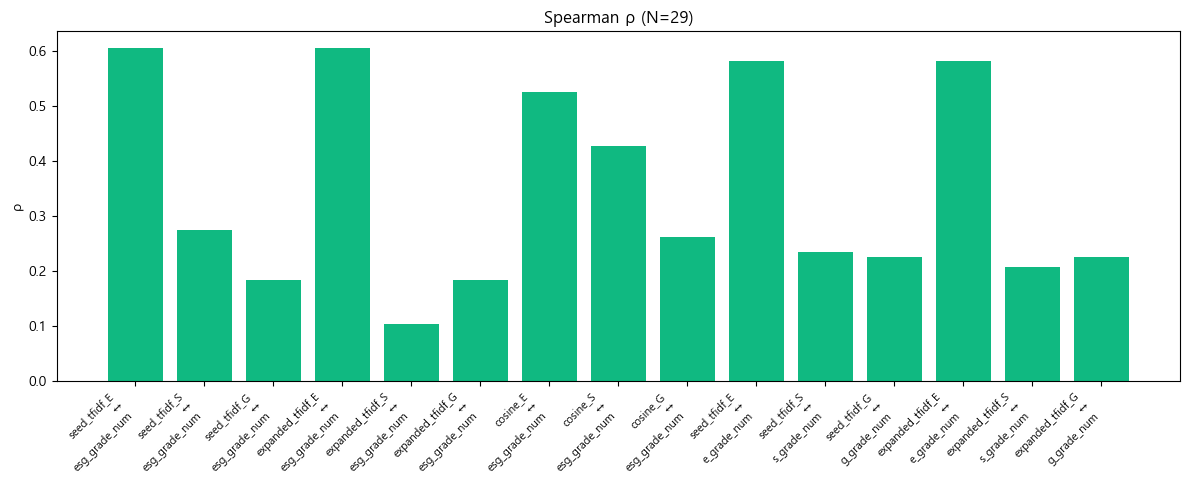

In [3]:
def feature_validity(df, score_col, grade_col):
    d = df.dropna(subset=[score_col, grade_col])
    n = len(d)
    if n < 3: return {'n': n, 'rho': np.nan, 'p': np.nan, 't_stat': np.nan, 't_p': np.nan}
    rho, p = stats.spearmanr(d[score_col], d[grade_col])
    med = d[grade_col].median()
    hi = d[d[grade_col] >= med][score_col]
    lo = d[d[grade_col] < med][score_col]
    if len(hi) < 2 or len(lo) < 2: ts, tp = np.nan, np.nan
    else: ts, tp = stats.ttest_ind(hi, lo, equal_var=False)
    return {'n': n, 'rho': rho, 'p': p, 't_stat': ts, 't_p': tp}

pairs = [
    ('seed_tfidf_E','esg_grade_num'), ('seed_tfidf_S','esg_grade_num'), ('seed_tfidf_G','esg_grade_num'),
    ('expanded_tfidf_E','esg_grade_num'), ('expanded_tfidf_S','esg_grade_num'), ('expanded_tfidf_G','esg_grade_num'),
    ('cosine_E','esg_grade_num'), ('cosine_S','esg_grade_num'), ('cosine_G','esg_grade_num'),
    ('seed_tfidf_E','e_grade_num'), ('seed_tfidf_S','s_grade_num'), ('seed_tfidf_G','g_grade_num'),
    ('expanded_tfidf_E','e_grade_num'), ('expanded_tfidf_S','s_grade_num'), ('expanded_tfidf_G','g_grade_num'),
]
validity = pd.DataFrame([
    {'feature': f, 'grade': g, **feature_validity(features, f, g)} for f, g in pairs
])
print('📊 feature_validity (Spearman + t-test)')
print(validity.to_string())

# 시각화 — Spearman ρ
if N >= 3:
    fig, ax = plt.subplots(figsize=(12, 5))
    valid_v = validity.dropna(subset=['rho'])
    if len(valid_v) > 0:
        x_labels = [f'{r["feature"]}\n↔\n{r["grade"]}' for _, r in valid_v.iterrows()]
        ax.bar(range(len(valid_v)), valid_v['rho'].values, color=['#10b981' if r > 0 else '#ef4444' for r in valid_v['rho']])
        ax.set_xticks(range(len(valid_v)))
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(f'Spearman ρ (N={N})')
        ax.set_ylabel('ρ')
        plt.tight_layout()
        plt.savefig(ROOT/'data'/'processed'/'fig_v_final_mining_spearman.png', dpi=120)
        plt.show()


---
## Step 3 — 🆕 OLS + ordered_logit + binary_logit 3 모형 (가이드 03 line 220-274)


In [4]:
try:
    import statsmodels.api as sm
    from statsmodels.miscmodels.ordinal_model import OrderedModel

    models_results = []

    if N >= 5:
        # OLS (가이드 03 line 230-237)
        X = features[['seed_tfidf_E','word_count']].dropna()
        if len(X) >= 4:
            X_ols = sm.add_constant(X)
            y = features.loc[X.index, 'esg_grade_num']
            ols = sm.OLS(y, X_ols).fit()
            models_results.append({'model': 'OLS_seed_E', 'beta1': ols.params.get('seed_tfidf_E', np.nan),
                                    'p': ols.pvalues.get('seed_tfidf_E', np.nan),
                                    'R²': ols.rsquared, 'AIC': ols.aic, 'BIC': ols.bic})

            # expanded 버전
            Xe = features[['expanded_tfidf_E','word_count']].dropna()
            if len(Xe) >= 4:
                ols_e = sm.OLS(features.loc[Xe.index,'esg_grade_num'], sm.add_constant(Xe)).fit()
                models_results.append({'model': 'OLS_expanded_E', 'beta1': ols_e.params.get('expanded_tfidf_E', np.nan),
                                        'p': ols_e.pvalues.get('expanded_tfidf_E', np.nan),
                                        'R²': ols_e.rsquared, 'AIC': ols_e.aic, 'BIC': ols_e.bic})

        # Ordered logit (가이드 03 line 240-247)
        if N >= 10:
            try:
                om = OrderedModel(features['esg_grade_num'].astype(int),
                                   features[['seed_tfidf_E','word_count']], distr='logit').fit(disp=False)
                models_results.append({'model': 'OrderedLogit_seed_E',
                                        'beta1': om.params.get('seed_tfidf_E', np.nan),
                                        'p': om.pvalues.get('seed_tfidf_E', np.nan),
                                        'R²': np.nan, 'AIC': om.aic, 'BIC': om.bic})
            except Exception as e:
                print(f'OrderedLogit 실패: {e}')

        # Binary logit (가이드 03 line 249-257)
        features['high'] = (features['esg_grade_num'] >= 4).astype(int)
        Xb = features[['seed_tfidf_E','word_count']].dropna()
        if Xb['seed_tfidf_E'].var() > 0:
            try:
                bl = sm.Logit(features.loc[Xb.index,'high'], sm.add_constant(Xb)).fit(disp=False)
                models_results.append({'model': 'BinaryLogit_seed_E (A이상)',
                                        'beta1': bl.params.get('seed_tfidf_E', np.nan),
                                        'p': bl.pvalues.get('seed_tfidf_E', np.nan),
                                        'R²': bl.prsquared, 'AIC': bl.aic, 'BIC': bl.bic})
            except Exception as e:
                print(f'Logit 실패: {e}')

    models_df = pd.DataFrame(models_results)
    print('📊 3 모형 비교')
    print(models_df.to_string() if len(models_df) > 0 else '(N 부족 — 사이클 4 batch 후 정상)')
except ImportError:
    print('⚠️ statsmodels 미설치 — pip install statsmodels')
    models_df = pd.DataFrame()


📊 3 모형 비교
                      model      beta1         p        R²         AIC         BIC
0                OLS_seed_E   7.364760  0.029152  0.295120  110.027584  114.129472
1            OLS_expanded_E   7.364760  0.029152  0.295120  110.027584  114.129472
2       OrderedLogit_seed_E  -0.005224  0.999350       NaN  112.056988  121.628058
3  BinaryLogit_seed_E (A이상)  41.092261  0.075054  0.364368   30.469354   34.571241


c:\Users\kik32\workspace\unstructured-data-processing-final-project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---
## Step 4 — 🆕 알파 #1: 업종별 분해 (가이드 04 §3-1)


📊 업종별 분해 (알파 #1)
  industry  n  mean_seed_E  mean_grade       rho         p
0     금융지주  3     0.011103    4.333333  0.866025  0.333333


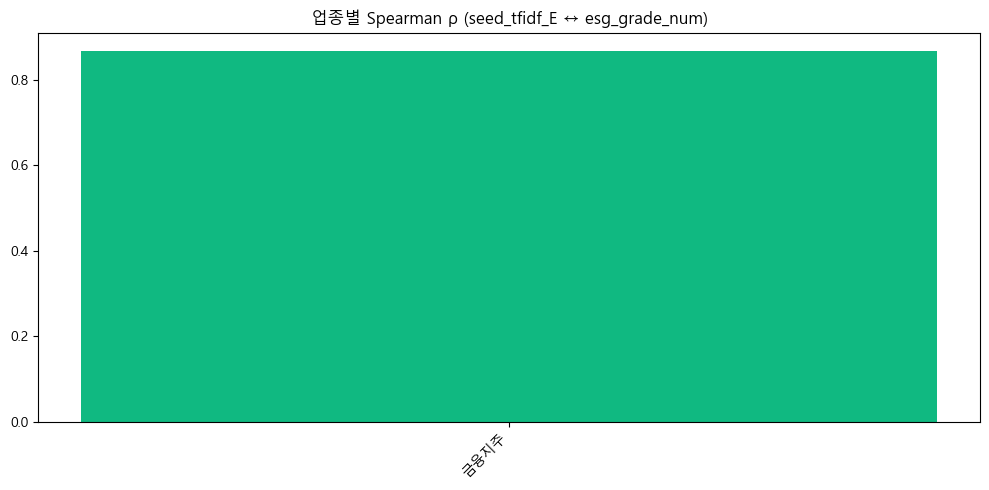

In [5]:
if N >= 10 and 'industry' in features.columns:
    industry_results = []
    for ind in features['industry'].unique():
        sub = features[features['industry']==ind]
        if len(sub) < 3: continue
        try:
            rho, p = stats.spearmanr(sub['seed_tfidf_E'], sub['esg_grade_num'])
        except: rho, p = np.nan, np.nan
        industry_results.append({'industry': ind, 'n': len(sub),
                                  'mean_seed_E': sub['seed_tfidf_E'].mean(),
                                  'mean_grade': sub['esg_grade_num'].mean(),
                                  'rho': rho, 'p': p})
    ind_df = pd.DataFrame(industry_results).sort_values('n', ascending=False)
    print('📊 업종별 분해 (알파 #1)')
    print(ind_df.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    ind_df_top = ind_df.head(10)
    ax.bar(range(len(ind_df_top)), ind_df_top['rho'].fillna(0),
           color=['#10b981' if r > 0 else '#ef4444' for r in ind_df_top['rho'].fillna(0)])
    ax.set_xticks(range(len(ind_df_top)))
    ax.set_xticklabels(ind_df_top['industry'].tolist(), rotation=45, ha='right')
    ax.set_title('업종별 Spearman ρ (seed_tfidf_E ↔ esg_grade_num)')
    ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(ROOT/'data'/'processed'/'fig_v_final_mining_industry.png', dpi=120)
    plt.show()
else:
    print(f'⚠️ N={N} — 업종 분해는 N≥10 필요 (사이클 4 batch 후)')


---
## Step 5 — 최종 결과 저장 + self-check


In [6]:
# 결과 csv 저장
results_path = ROOT/'data'/'processed'/'regression_results_v_final.csv'
all_results = {'validity': validity, 'models': models_df}
combined = pd.concat([
    validity.assign(type='validity').rename(columns={'feature':'feature_or_model'}),
    models_df.assign(type='model').rename(columns={'model':'feature_or_model','beta1':'rho'})
], ignore_index=True) if len(models_df) > 0 else validity
combined.to_csv(results_path, index=False, encoding='utf-8-sig')
print(f'💾 {results_path.name}')

# self-check
final = [
    ('N firm-year', N, 'sufficient' if N >= 30 else 'limited'),
    ('Spearman 9~15 쌍', f'{len(validity)} 계산', '✅ 코드'),
    ('OLS 모형', f'{(models_df["model"].str.startswith("OLS")).sum() if len(models_df) else 0}', '가이드 03 line 230'),
    ('Ordered Logit', f'{(models_df["model"].str.contains("Ordered")).sum() if len(models_df) else 0}', '가이드 03 line 240'),
    ('Binary Logit', f'{(models_df["model"].str.contains("Binary")).sum() if len(models_df) else 0}', '가이드 03 line 249'),
    ('업종 분해 알파', '✅' if N >= 10 else '⏳ N≥10', '가이드 04 §3-1'),
    ('cheap-talk 통제', '✅ word_count + specificity', 'ClimateBert 라인'),
]
print('\n📋 03_mining v_final self-check')
print(pd.DataFrame(final, columns=['항목','값','근거']).to_string())

print(f'\n🎯 사이클 4 완료. 다음: 사이클 5 (모형 검증·알파 추가·발표 자료)')


💾 regression_results_v_final.csv

📋 03_mining v_final self-check
                항목                           값               근거
0      N firm-year                          29          limited
1  Spearman 9~15 쌍                       15 계산             ✅ 코드
2           OLS 모형                           2  가이드 03 line 230
3    Ordered Logit                           1  가이드 03 line 240
4     Binary Logit                           1  가이드 03 line 249
5         업종 분해 알파                           ✅      가이드 04 §3-1
6    cheap-talk 통제  ✅ word_count + specificity   ClimateBert 라인

🎯 사이클 4 완료. 다음: 사이클 5 (모형 검증·알파 추가·발표 자료)
